# Assignment 2: Engineering Predictive Features

**Student Name:** [Seth Logan]

**Date:** [2/5/26]

---

## Assignment Overview

In this assignment, you'll practice feature engineering by creating new predictive features from the Ames Housing dataset. You'll build a baseline model with raw features, engineer at least 5 new features based on real estate intuition, and measure how feature engineering improves model performance.

---

## Step 1: Import Libraries and Load Data

In [50]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [51]:
# Load the Ames Housing dataset
# TODO: Load train.csv from the data folder
df =  pd.read_csv("data/train.csv")  # Replace with pd.read_csv()

# Display basic information
# TODO: Display the first few rows and basic info about the dataset
display(df.head())
df.info()

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Dataset shape: {df.shape if df is not None else 'Not loaded'}")
print("="*80)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

---
## Step 2: Build Baseline Model with Raw Features

### Select Raw Features for Baseline

Select 10-15 raw features to use in your baseline model. Here's a suggested starting set (you can adjust):

**Suggested features:**
- `GrLivArea` - Above grade living area square feet
- `OverallQual` - Overall material and finish quality
- `YearBuilt` - Original construction year
- `TotalBsmtSF` - Total basement square feet
- `FullBath` - Full bathrooms above grade
- `BedroomAbvGr` - Bedrooms above grade
- `GarageArea` - Size of garage in square feet
- `LotArea` - Lot size in square feet
- `Neighborhood` - Physical location (categorical)
- Add 5-10 more features you think are important

In [52]:
# Select features for baseline model
# TODO: Create a list of feature names you want to use
baseline_features = [
    'GrLivArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'TotalBsmtSF',
    'HalfBath',
    'FullBath',
    'KitchenQual',
    'PoolArea',
    'BedroomAbvGr',
    'GarageArea',
    'LotFrontage',
    'LotArea',
    'HouseStyle',
    'Neighborhood',
    'YearBuilt',
    'YrSold',
    'SaleCondition'
    # Add more features here
]

# TODO: Create X (features) and y (target) for baseline
# Make sure to handle missing values and encode categorical variables
X_baseline = df[baseline_features].copy()  # Replace with your feature matrix
y = df['SalePrice']  # Replace with df['SalePrice']

print(f"Baseline features selected: {len(baseline_features)}")
print(f"Target variable shape: {y.shape if y is not None else 'Not defined'}")

Baseline features selected: 18
Target variable shape: (1460,)


### Preprocess Baseline Features

In [53]:
# Handle missing values
# TODO: Fill missing values appropriately
# Numeric: Use median or 0
# Categorical: Use 'None' or most frequent
numeric_cols = X_baseline.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_baseline.select_dtypes(include=['object', 'category']).columns

for col in numeric_cols:
    X_baseline[col] = X_baseline[col].fillna(X_baseline[col].median())

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].fillna('None')


# Encode categorical variables
# TODO: Use pd.get_dummies() for categorical features
X_baseline = pd.get_dummies(X_baseline, columns=categorical_cols, drop_first=True)

print("\n" + "="*80)
print("CHECKPOINT: After preprocessing")
print(f"X_baseline shape: {X_baseline.shape if X_baseline is not None else 'Not defined'}")
print(f"Missing values: {X_baseline.isnull().sum().sum() if X_baseline is not None else 'N/A'}")
print("="*80)


CHECKPOINT: After preprocessing
X_baseline shape: (1460, 53)
Missing values: 0


### Train Baseline Model

In [54]:
# Split data into train and test sets
# TODO: Use train_test_split with test_size=0.2, random_state=42
X_train, X_test, y_train, y_test = train_test_split(X_baseline,y, test_size=0.2, random_state=42) # Replace with train_test_split()

# Train baseline Random Forest model
# TODO: Create and train RandomForestRegressor(n_estimators=100, random_state=42)
baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)  # Replace with trained model

# Make predictions
# TODO: Generate predictions on test set
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)  # Replace with predictions

# Calculate metrics
# TODO: Calculate R² and RMSE
baseline_r2 = r2_score(y_test, baseline_predictions)  # Replace with r2_score()
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_predictions))  # Replace with np.sqrt(mean_squared_error())

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"R² Score: {baseline_r2 if baseline_r2 is not None else 'Not calculated'}")
print(f"RMSE: ${baseline_rmse:,.2f}" if baseline_rmse is not None else "RMSE: Not calculated")
print("="*80)


BASELINE MODEL RESULTS
R² Score: 0.8736735321198905
RMSE: $31,128.21


### Visualize Baseline Feature Importances

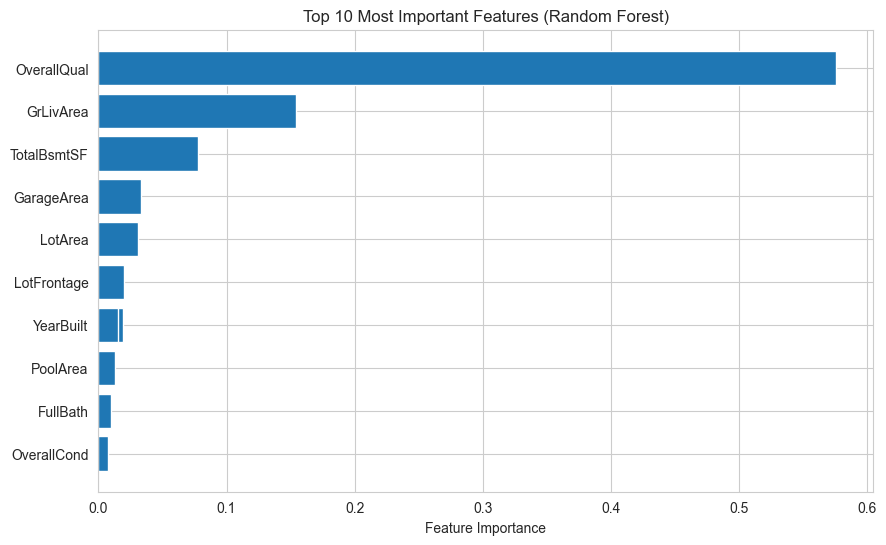


CHECKPOINT: Review which raw features are most important


In [55]:
# Extract and visualize feature importances
# TODO: Get feature importances from baseline_model

feature_importances = baseline_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': X_baseline.columns,
    'importance': feature_importances
})

top_10_features = importance_df.sort_values(
    by='importance',
    ascending=False
).head(11)

# TODO: Create a horizontal bar plot of top 10 features

plt.figure(figsize=(10, 6))
plt.barh(top_10_features['feature'], top_10_features['importance'])
plt.gca().invert_yaxis()  # Most important feature at top
plt.xlabel("Feature Importance")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.show()

print("\n" + "="*80)
print("CHECKPOINT: Review which raw features are most important")
print("="*80)

---
## Step 3: Engineer New Features

### Feature 1: [Total Living Area] - [Living Space]

**Business Justification:**
[The overall size of the living space will measure the space of a home by combining the ground living area and basement space. Typically, larger homes will demand a higher price because they offer more flexibility. Buyers tend to look at the overall living area, rather than seperating the areas.]

In [56]:
# TODO: Create your first engineered feature
# Example: df['total_bathrooms'] = df['FullBath'] + 0.5 * df['HalfBath']

df['living_area'] = df['GrLivArea'] + df['TotalBsmtSF']
#Show calculation worked
print(df['living_area'].head())


0    2566
1    2524
2    2706
3    2473
4    3343
Name: living_area, dtype: int64


### Feature 2: [True Age of House] - [Updated Age]

**Business Justification:**
[This new feature captures how updated numerical value of build year/remodel year to find the "true" age of the home at sale. A fully remodeled home competes with newer homes and this feature shows this better than raw age.]

In [57]:
# TODO: Create your second engineered feature

df['true_age'] = df['YrSold'] - df[['YearBuilt', 'YearRemodAdd']].max(axis=1)
print(df['true_age'].head())

0     5
1    31
2     6
3    36
4     8
Name: true_age, dtype: int64


### Feature 3: [Outdoor Space] - [Available Land]

**Business Justification:**
[The total outdoor feature the total amount of usable available space. Homes with added outdoor living areas attract buyers because they offer more activity options. A high total outdoor space can cause a price premium.]

In [58]:
# TODO: Create your third engineered feature

df['total_outdoor'] = df['WoodDeckSF'] + df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['PoolArea']
print(df['total_outdoor'].head())

0     61
1    298
2     42
3    307
4    276
Name: total_outdoor, dtype: int64


### Feature 4: [Room Area] - [Layout Efficiency]

**Business Justification:**
[This feature measures how efficiently a home’s living space is distributed across rooms. Buyers tend to prefer homes with more spacious rooms rather than many small rooms. A higher square footage per room often translates to a more desirable floor plan, which increases home prices.]

In [59]:
# TODO: Create your fourth engineered feature

df['per_room'] = df['GrLivArea'] / df['TotRmsAbvGrd'].replace(0, 1)
print(df['per_room'].head())

0    213.750000
1    210.333333
2    297.666667
3    245.285714
4    244.222222
Name: per_room, dtype: float64


In [60]:
# Identify what the Kitchen Quality values are
print(df['KitchenQual'])

0       Gd
1       TA
2       Gd
3       Gd
4       Gd
        ..
1455    TA
1456    TA
1457    Gd
1458    Gd
1459    TA
Name: KitchenQual, Length: 1460, dtype: object


### Feature 5: [Quality Score] - [House Quality]

**Business Justification:**
[This feature combines quality and condition indicators into a single composite score that reflects the overall build and finish of the home. Buyers tend to evaluate homes based on construction quality, interior, and maintenance rather than individual components. Combining these signals provides a clearer measure of actual home quality, which strongly influences sale price.]

In [61]:
# TODO: Create your fifth engineered feature


df['quality_score'] = (
    df['OverallQual'] +
    df['OverallCond'] +
    df['KitchenQual'].map({'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1})
)

print(df['quality_score'].sample(5))

892     17
1105    17
413     14
522     16
1036    19
Name: quality_score, dtype: int64


---
## Step 4: Train Model with Engineered Features

In [62]:
# Create feature list combining baseline + engineered features
# TODO: List all your engineered feature names
engineered_features = [
    'living_area',
    'true_age',
    'total_outdoor',
    'per_room',
    'quality_score'
    # Add your engineered feature names here
]

# Combine baseline and engineered features
all_features = baseline_features + engineered_features

# TODO: Create X_engineered with all features
# Remember to handle missing values and encode categoricals
X_engineered =  df[all_features].copy() # Replace with your feature matrix

print(f"Total features in engineered model: {len(all_features)}")
print(f"New engineered features: {len(engineered_features)}")

Total features in engineered model: 23
New engineered features: 5


In [63]:
X_engineered = pd.get_dummies(
    X_engineered,
    columns=['KitchenQual', 'HouseStyle', 'Neighborhood', 'SaleCondition'],
    drop_first=True
)

In [64]:
# Split data (use same random_state for fair comparison)
# TODO: Split X_engineered and y
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)

# Train model with engineered features
# TODO: Train train_test_split( X_engineered, y, test_size=0.2, random_state=42)
engineered_model =  RandomForestRegressor(
    n_estimators=100,
    random_state=42
 )

# Make predictions
# TODO: Generate predictions on test set
engineered_model.fit(X_train_eng, y_train_eng)
engineered_predictions =  engineered_model.predict(X_test_eng) # Replace with predictions

# Calculate metrics
# TODO: Calculate R² and RMSE
engineered_r2 = r2_score(y_test_eng, engineered_predictions) # Replace with r2_score()
engineered_rmse = np.sqrt(mean_squared_error(y_test_eng, engineered_predictions))  # Replace with np.sqrt(mean_squared_error())

print("\n" + "="*80)
print("ENGINEERED MODEL RESULTS")
print("="*80)
print(f"R² Score: {engineered_r2 if engineered_r2 is not None else 'Not calculated'}")
print(f"RMSE: ${engineered_rmse:,.2f}" if engineered_rmse is not None else "RMSE: Not calculated")
print("="*80)


ENGINEERED MODEL RESULTS
R² Score: 0.8739392409062874
RMSE: $31,095.45


---
## Step 5: Compare Models and Identify Most Valuable Features

### Create Comparison Table

In [65]:
# Create comparison DataFrame
# TODO: Create a table comparing baseline vs engineered model
comparison = pd.DataFrame({
    "Model": ["Baseline Model", "Engineered Model"],
    "R² Score": [baseline_r2, engineered_r2],
    "RMSE": [baseline_rmse, engineered_rmse]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
# TODO: Display comparison table

print(comparison)
print("="*80)

# Calculate improvement
if baseline_r2 is not None and engineered_r2 is not None:
    r2_improvement = ((engineered_r2 - baseline_r2) / baseline_r2) * 100
    rmse_improvement = ((baseline_rmse - engineered_rmse) / baseline_rmse) * 100
    print(f"\nR² Improvement: {r2_improvement:.2f}%")
    print(f"RMSE Improvement: {rmse_improvement:.2f}%")


MODEL COMPARISON
              Model  R² Score          RMSE
0    Baseline Model  0.873674  31128.206136
1  Engineered Model  0.873939  31095.452146

R² Improvement: 0.03%
RMSE Improvement: 0.11%


### Visualize Feature Importances from Engineered Model

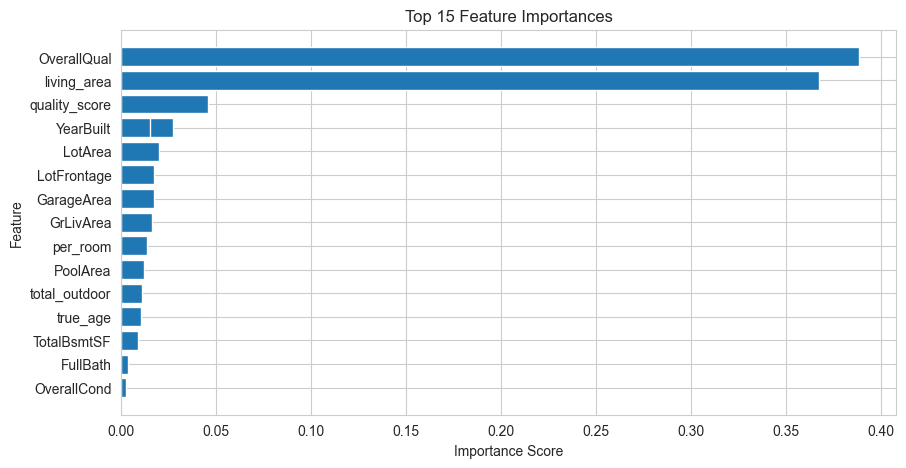

In [66]:
# Extract and visualize top 15 feature importances
# TODO: Get feature importances from engineered_model
# TODO: Create horizontal bar plot of top 15 features

importances = engineered_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X_engineered.columns,
    "Importance": importances
})

# Top 15
top_15_features = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).head(16)


plt.figure(figsize=(10, 5))
plt.barh(
    top_15_features["Feature"],
    top_15_features["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

### Analysis: Most Valuable Features

**Write 3-5 bullet points analyzing your results:**

- All 5 of my engineered features were featured in the top 15 most important features, with 2 of my calculated features ranking within the top 3 (living_area at #2, quality_score at #3).
- The engineered feature perfomed well amongst the given characteristics because reduce redundancy. Additionally, the new features relied on other features that already had high importance scores.
- None of my engineered features fell significantly lower than I expected, but I did think my 'quality_score' feature would have taken the top spot of any characteristic.
- From this analysis I learned that effective feature engineering is less about adding more features and more about implementing meaningful structure to existing data.
- If I created additional features, future efforts would directly focus on features involving neighborhood and other features that were lower on the importance scale.

---
## Step 6: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have at least 5 engineered features with business justifications
3. Check that your comparison table and visualizations display correctly
4. Complete the analysis section above

Then push to GitHub:
```bash
git add .
git commit -m 'completed feature engineering assignment'
git push
```

Submit your GitHub repository link on the course platform.